<a href="https://colab.research.google.com/github/yo-danny/urban-time-series-comparison/blob/main/notebooks/urban_time_series_comparison_traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Initial Imports and Reading the Dataset

In [1]:
import pandas as pd
import kagglehub
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler

In [2]:
kagglehub.dataset_download("annnnguyen/metr-la-dataset")

Using Colab cache for faster access to the 'metr-la-dataset' dataset.


'/kaggle/input/metr-la-dataset'

In [3]:
dataset_path = '/kaggle/input/metr-la-dataset'
file_name = 'METR-LA.h5'
full_file_path = os.path.join(dataset_path, file_name)

df = pd.read_hdf(full_file_path)

display(df.head())

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


Converted the index to datetime format  for better understanding and use of the dataset.

In [4]:
df.index = pd.DatetimeIndex(df.index.values, freq='infer')

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34272 entries, 2012-03-01 00:00:00 to 2012-06-27 23:55:00
Freq: 5min
Columns: 207 entries, 773869 to 769373
dtypes: float64(207)
memory usage: 54.4 MB


## Exploratory Data Analysis

### Basic Informations

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
773869,34272.0,54.631359,22.619199,0.0,60.364583,64.888889,66.875000,70.0
767541,34272.0,60.452789,15.970239,0.0,63.000000,65.000000,66.375000,70.0
767542,34272.0,60.726120,18.313353,0.0,65.444444,67.375000,68.444444,70.0
717447,34272.0,49.524287,15.843261,0.0,50.333333,53.875000,58.125000,70.0
717446,34272.0,46.079798,19.350345,0.0,34.666667,46.000000,64.500000,70.0
...,...,...,...,...,...,...,...,...
717592,34272.0,56.915083,18.260438,0.0,60.222222,63.000000,64.750000,70.0
717595,34272.0,62.484679,16.959238,0.0,65.888889,67.625000,68.625000,70.0
772168,34272.0,54.697381,16.303651,0.0,50.125000,61.125000,64.444444,70.0
718141,34272.0,58.920210,19.080474,0.0,62.888889,66.125000,67.750000,70.0


Checking for nulls

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


Checking the index collumn

In [ ]:
print(df.index)
print(df.index.is_monotonic_increasing)
print(df.index.is_unique)
print(df.index.to_series().diff().value_counts())

DatetimeIndex(['2012-03-01 00:00:00', '2012-03-01 00:05:00',
               '2012-03-01 00:10:00', '2012-03-01 00:15:00',
               '2012-03-01 00:20:00', '2012-03-01 00:25:00',
               '2012-03-01 00:30:00', '2012-03-01 00:35:00',
               '2012-03-01 00:40:00', '2012-03-01 00:45:00',
               ...
               '2012-06-27 23:10:00', '2012-06-27 23:15:00',
               '2012-06-27 23:20:00', '2012-06-27 23:25:00',
               '2012-06-27 23:30:00', '2012-06-27 23:35:00',
               '2012-06-27 23:40:00', '2012-06-27 23:45:00',
               '2012-06-27 23:50:00', '2012-06-27 23:55:00'],
              dtype='datetime64[ns]', length=34272, freq='5min')
True
True
0 days 00:05:00    34271
Name: count, dtype: int64


### Distributions

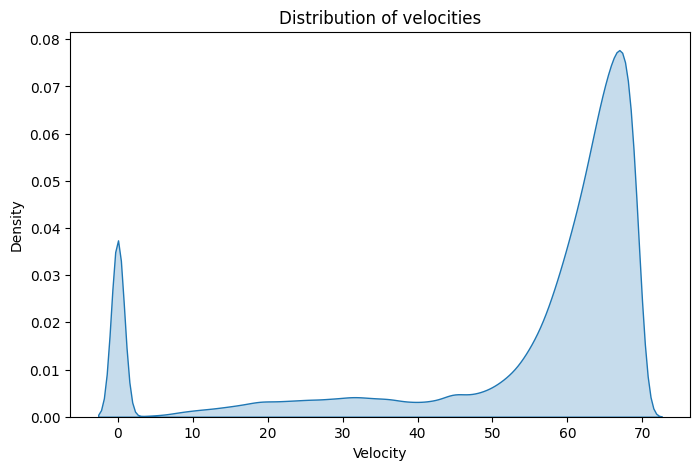

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(df.values.flatten(), fill=True)

plt.xlabel("Velocity")
plt.title("Distribution of velocities")
plt.show()

The bimodal distribution of velocities highlights a clear contrast: one peak at zero represents stationary traffic, while the other around 65 mph indicates free-flow conditions with no traffic congestion.

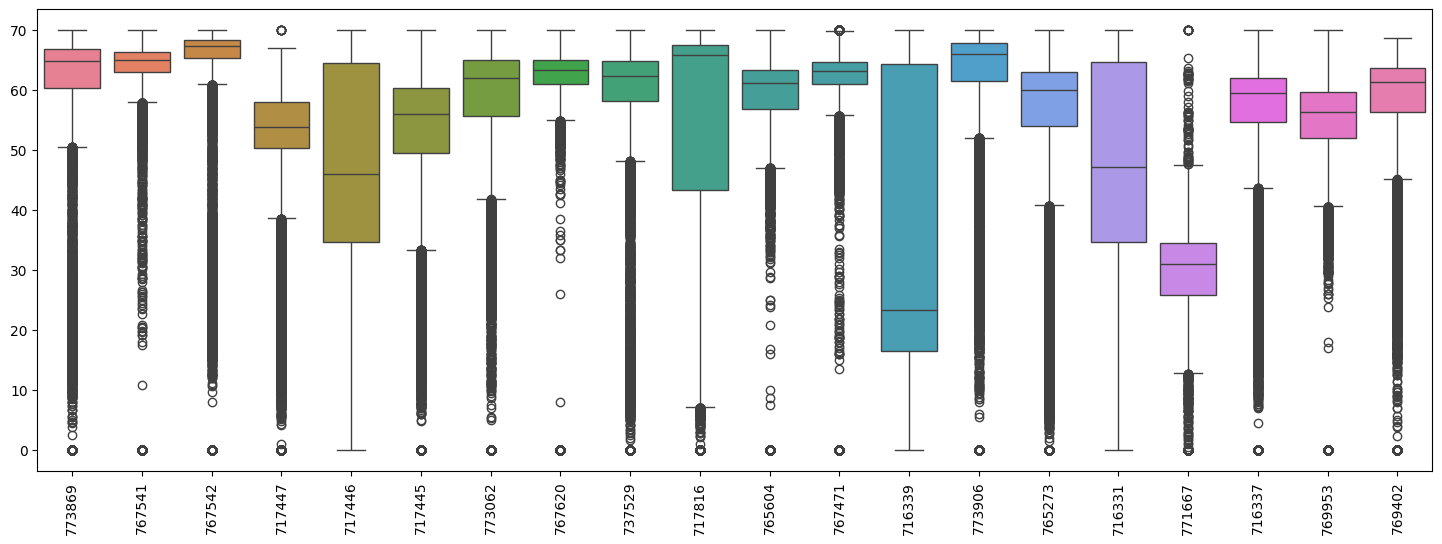

In [ ]:
plt.figure(figsize=(18,6))
sns.boxplot(data=df.iloc[:, :20])

plt.xticks(rotation=90)
plt.show()

The box-plot analysis of the 20 sensors reveals variations in velocity across different sensors. While most sensors record velocities primarily above 40 mph, four exhibit wider distributions, and one is significantly shifted downward.

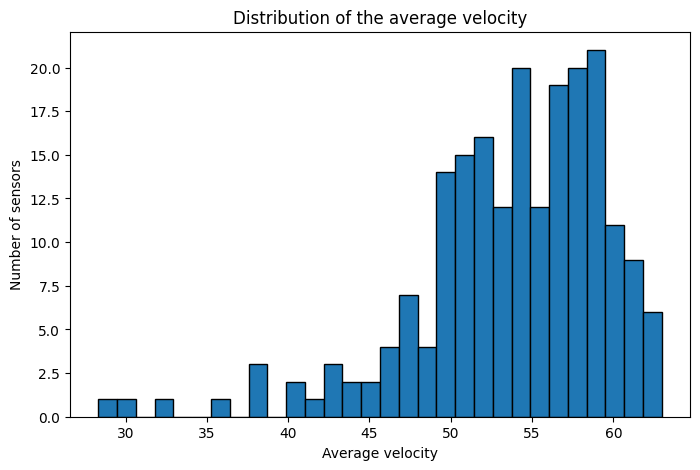

In [ ]:
sensor_mean = df.mean()

plt.figure(figsize=(8,5))
plt.hist(sensor_mean, bins=30, edgecolor='black')

plt.xlabel("Average velocity")
plt.ylabel("Number of sensors")
plt.title("Distribution of the average velocity")
plt.show()

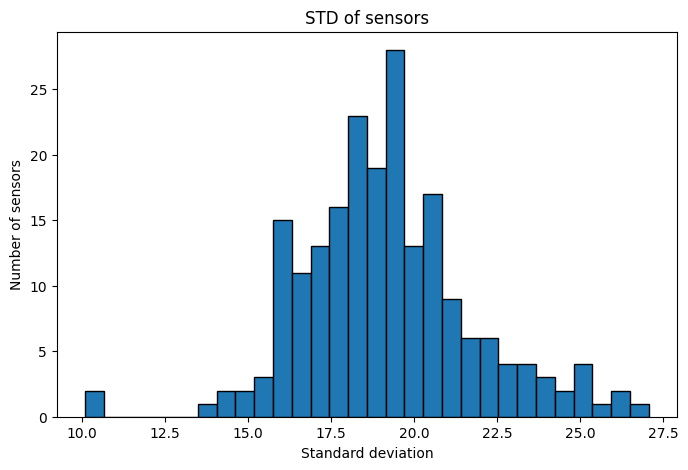

In [ ]:
sensor_std = df.std()

plt.figure(figsize=(8,5))
plt.hist(sensor_std, bins=30, edgecolor='black')

plt.xlabel("Standard deviation")
plt.ylabel("Number of sensors")
plt.title("STD of sensors")
plt.show()

The standard deviation ranges between 10 and 27, which is a narrow interval that indicates the absence of both outliers and constant sensor readings.

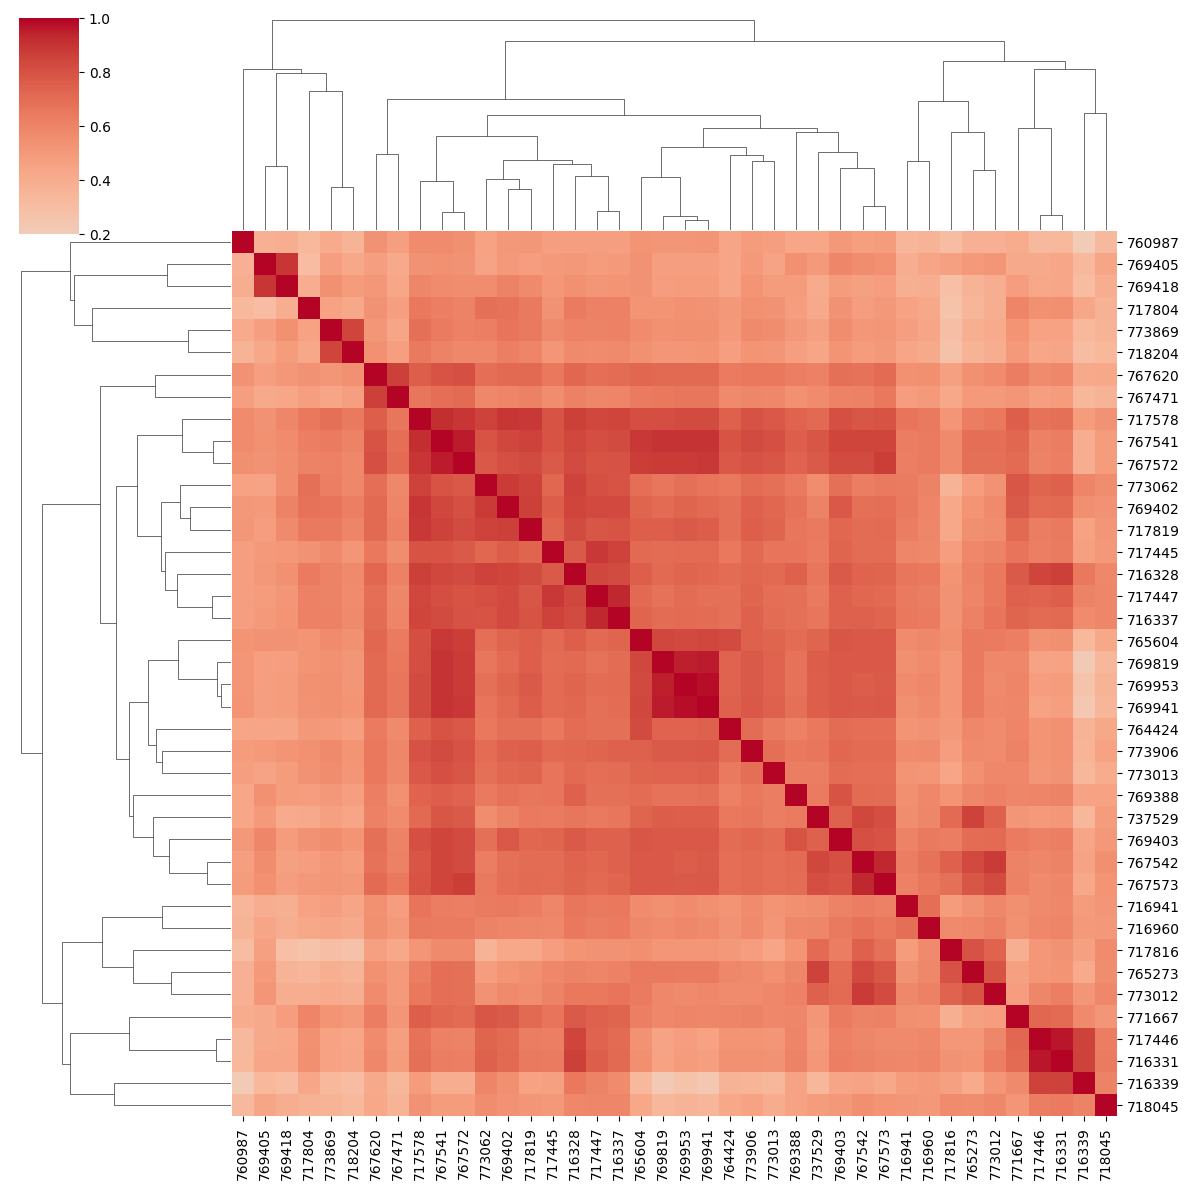

In [ ]:
corr = df.iloc[:, :40].corr()

sns.clustermap(
    corr,
    cmap="coolwarm",
    figsize=(12,12),
    center=0
)

plt.show()

### Checking other variables

**Outliers**

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
print("Percentual of outliers:", outliers.mean().mean() * 100)
percentual_outliers = outliers.mean() * 100
percentual_outliers.sort_values(ascending=False)

Percentual of outliers: 11.919703469149335


,0
773012,24.133403
763995,23.424370
717481,21.431489
716942,21.022993
718204,20.944211
...,...
717462,0.000000
717508,0.000000
717458,0.000000
717450,0.000000


The dataset has a mean of 11% of outlier velocities, the max value is 24% in a single sensor.

**Sazonality**

<Axes: >

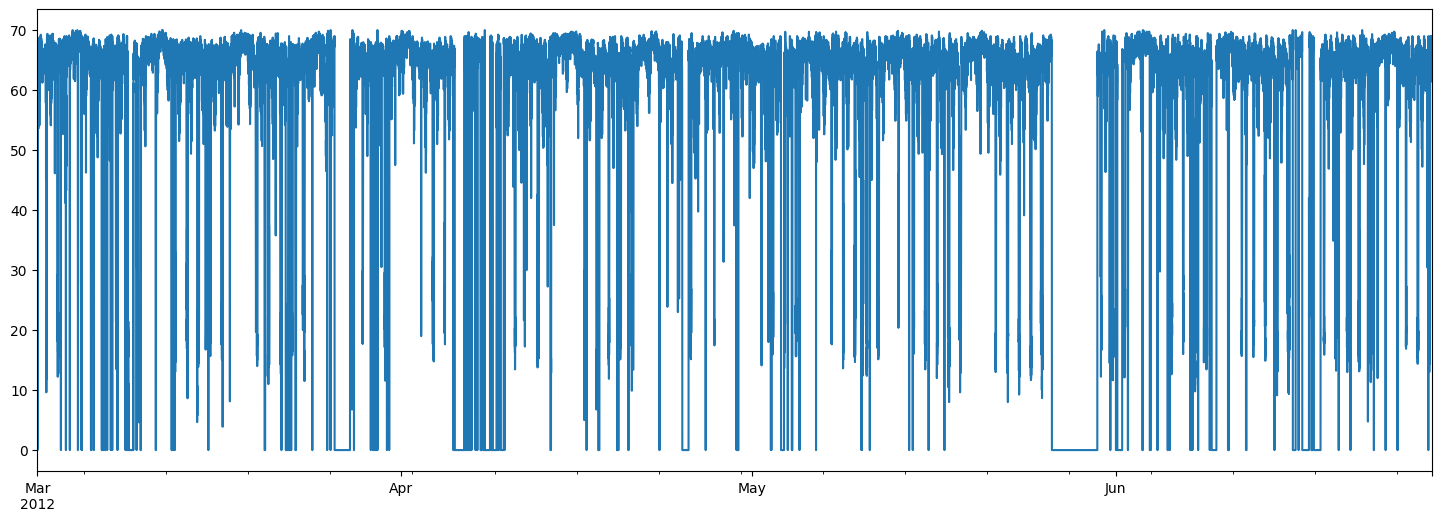

In [ ]:
df.iloc[:,0].plot(figsize=(18,6))

<Axes: xlabel='time'>

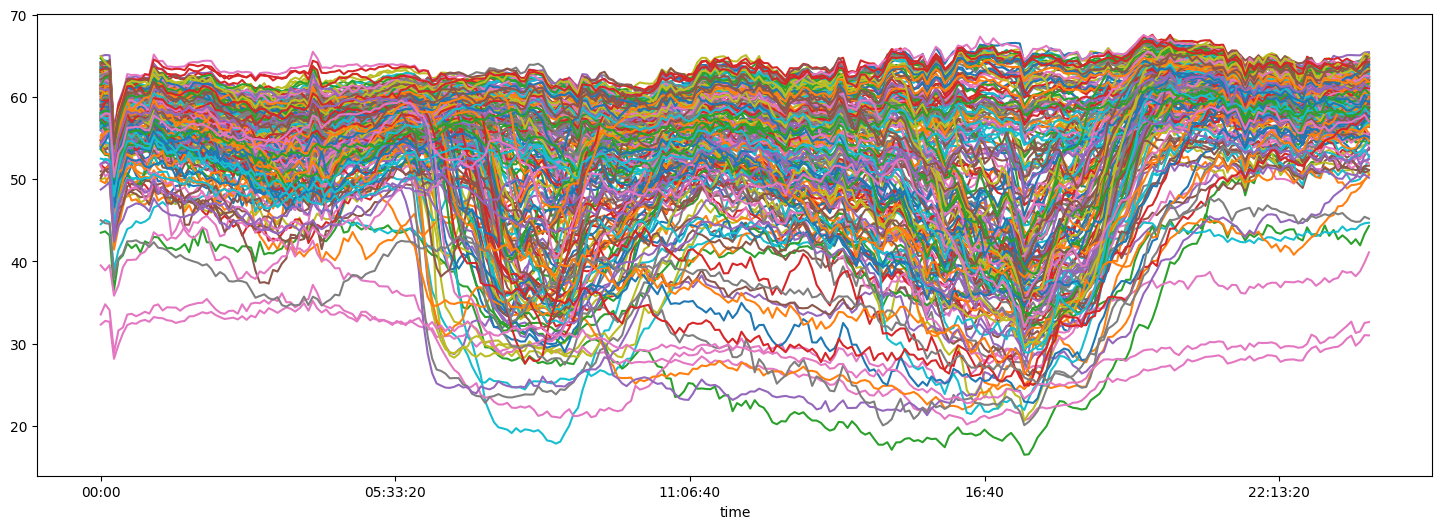

In [ ]:
daily = df.groupby(df.index.time).mean()

daily.plot(figsize=(18,6), legend=False)

The velocities decrease during the morning and around 17:00, corresponding to daily rush hours when commuting to work, school, or home is at its peak.

**Auto correlation**

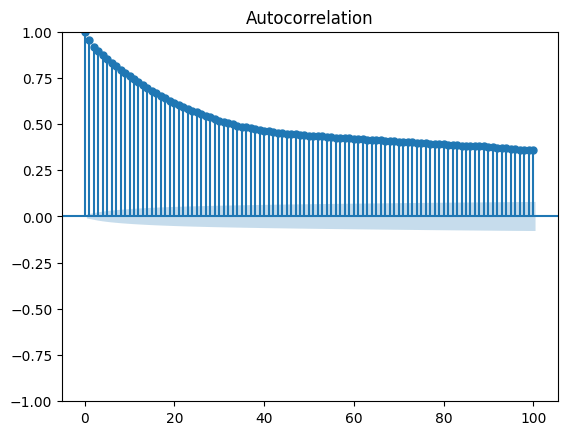

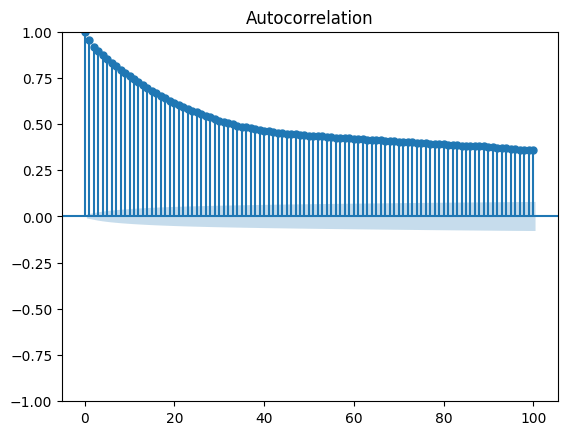

In [ ]:
plot_acf(df.iloc[:,0], lags = 100)

The autocorrelation peaks at lag 0 and decays gradually; however, it remains significant even at lag 100 (approximately 0.40), indicating a highly persistent process.

**Stationarity**

In [ ]:
result = adfuller(df.iloc[:,0])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -12.001047
p-value: 0.000000


The p-value is below 0.05, rejecting the null hypothesis, while the ADF statistic of -12 indicates that the series is stationary.

**Trend**

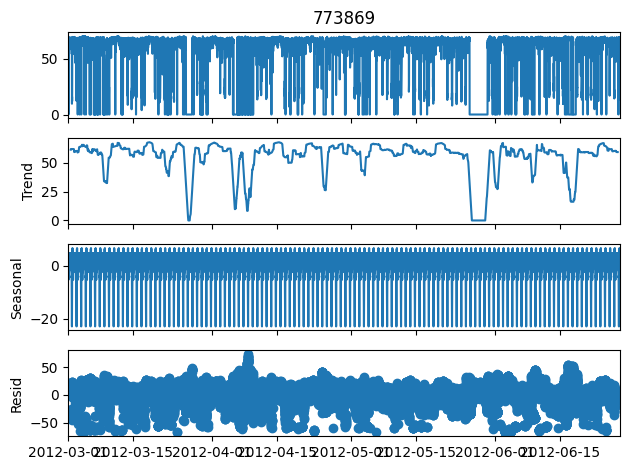

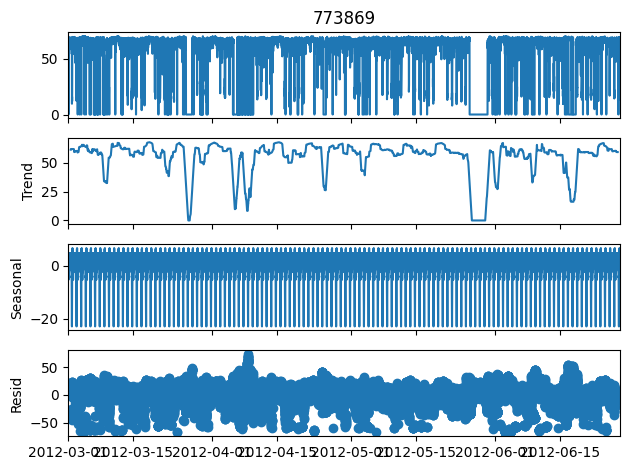

In [ ]:
decomp = seasonal_decompose(
    df.iloc[:,0],
    period=288
)

decomp.plot()

The seasonality shows a perfectly regular pattern, indicating a strong periodic cycle. However, there is a large dispersion in the residuals and several abrupt drops in velocity, suggesting an anomaly or data capture failure.

## Pre-Processing

As seen on the plots before, there is some 0 values between captures that possibly indicates a failure on getting the actual velocity. To handle those anomalies we turn these suspectful 0 into NaN values and, using  a linear interpolation we can infere what would be the velocity on that sensor.

**Detecting Possible Anomalies**

How do we know if a 0 is because of a failure on the capture or if it is just because of traffic? Basically, we will compare the velocities captured before and after the 0, if it is a considerable velocity we can infere it was an error.

In [7]:
def substitute_abnormal_zero(serie, limit=10):
  serie = serie.copy().astype(float)
  zeros = (serie == 0).values

  i = 0
  while i < len(serie):
    if zeros[i]:
      start = i
      while i < len(serie) and zeros[i]:
        i += 1
      end = i - 1
      bf = start - 1
      af = end + 1

      if (
          bf >= 0 and
          af < len(serie) and
          serie.iloc[bf] > limit and
          serie.iloc[af] > limit
      ):
        serie.iloc[start:end+1] = np.nan
    else:
      i += 1

  return serie

In [8]:
df = df.apply(substitute_abnormal_zero)

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-03-01 00:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Inferring Abnormal Zeros**

Now that we substitued the abnormal zeros with NaN, we can use the linear interpolation to infere what would be the possible value of that field.

In [21]:
df_interpolated = df.interpolate(method="linear", axis=0, limit_direction="both")

,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125000,67.125000,59.625000,62.750000,...,45.625000,65.500000,64.500000,66.428571,66.875000,59.375000,69.000000,59.250000,69.000000,61.875000
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875000,66.666667,58.555556,62.000000,61.111111,64.444444,55.888889,68.444444,62.875000
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000000,56.500000,59.250000,68.125000,62.500000,65.625000,61.375000,69.857143,62.000000
2012-03-01 00:15:00,61.777778,65.500000,62.555556,59.888889,66.777778,67.166667,63.222222,65.277778,63.583333,64.694444,...,43.416667,69.333333,60.444444,58.611111,67.416667,59.888889,65.305556,60.138889,69.571429,60.444444
2012-03-01 00:20:00,59.555556,67.250000,65.111111,60.777778,67.055556,68.083333,61.944444,66.305556,63.291667,64.013889,...,42.708333,69.666667,64.388889,57.972222,66.708333,57.277778,64.986111,58.902778,69.285714,58.888889


In [22]:
print(df.shape)
print(df.isna().sum().sum())

# Number of NaNs per sensor
print(df.isna().sum().describe())

(34272, 207)
564744
count     207.000000
mean     2728.231884
std       829.156610
min      1570.000000
25%      2180.000000
50%      2307.000000
75%      3060.500000
max      6875.000000
dtype: float64
